In [108]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import *
from sklearn.metrics import *
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [109]:
df = pd.read_csv("California_Houses.csv")

In [110]:
df.head(1000)

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,192400.0,4.8624,11,12070,2220,5826,2125,37.71,-121.75,36153.866009,514897.043562,694185.562163,43513.047534,60327.280077
996,418800.0,9.1531,25,494,81,254,85,37.74,-121.77,33031.749658,518598.446233,697894.584524,46270.099629,58258.658680
997,216800.0,4.7361,22,5533,943,2474,910,37.70,-121.80,32560.957256,516809.796810,696048.481745,41354.831656,56119.751279
998,215500.0,5.4324,17,3956,639,2222,662,37.69,-121.80,32301.734489,515950.596782,695179.986203,40265.702643,56297.167678


In [111]:
y = df['Median_House_Value']
x = df[['Median_Income',	'Median_Age',	'Tot_Rooms'	,'Tot_Bedrooms',	'Population',	'Households',	'Latitude',	'Longitude',	'Distance_to_coast',	'Distance_to_LA',	'Distance_to_SanDiego',	'Distance_to_SanJose',	'Distance_to_SanFrancisco']]

In [129]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 100, shuffle = True)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size = 0.5, random_state = 100, shuffle = True)


In [130]:
# np.array(x_train).shape
# np.array(x_test).shape
# np.array(x_val).shape

# np.array(y_train).shape
# np.array(y_test).shape
# np.array(y_val).shape

In [131]:
# x_train = np.array(x_train).reshape(-1, 1)
# x_test = np.array(x_test).reshape(-1, 1)
# x_val = np.array(x_val).reshape(-1, 1)


y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)
y_val = np.array(y_val).reshape(-1, 1)

In [132]:
# np.array(y_train).shape
np.array(y_test).shape
# np.array(y_val).shape

(3096, 1)

In [133]:
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
x_val=scaler.transform(x_val)

In [134]:
lr = LinearRegression()

In [135]:
lr.fit(x_train, y_train)

LinearRegression()

In [136]:
y_train_predict = lr.predict(x_train)


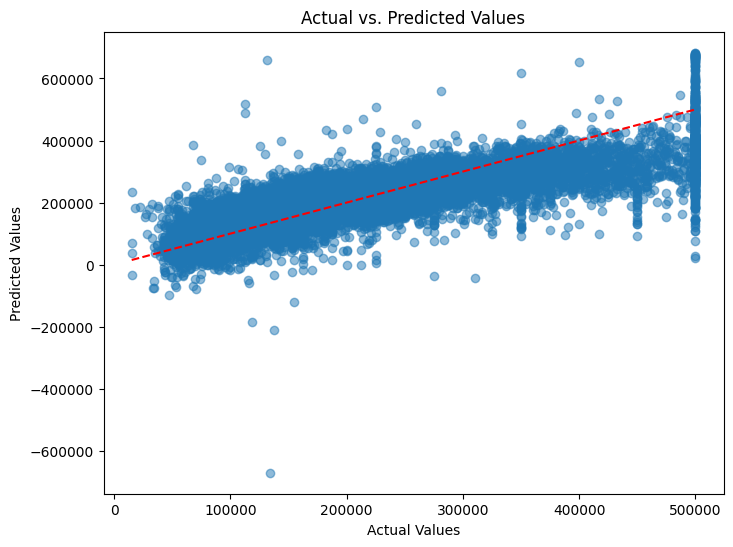

In [137]:
y_train = y_train.flatten()
y_train_predict = y_train_predict.flatten()

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_predict, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()


In [144]:
mse = mean_squared_error(y_train, y_train_predict)
mae = mean_absolute_error(y_train, y_train_predict)
print(mse)
print(mae)

4814917621.605248
50307.568737046466


In [138]:
y_val_prediction = lr.predict(x_val)

In [139]:
np.array(y_val).shape

(3096, 1)

In [140]:
np.array(y_val_prediction).shape

(3096, 1)

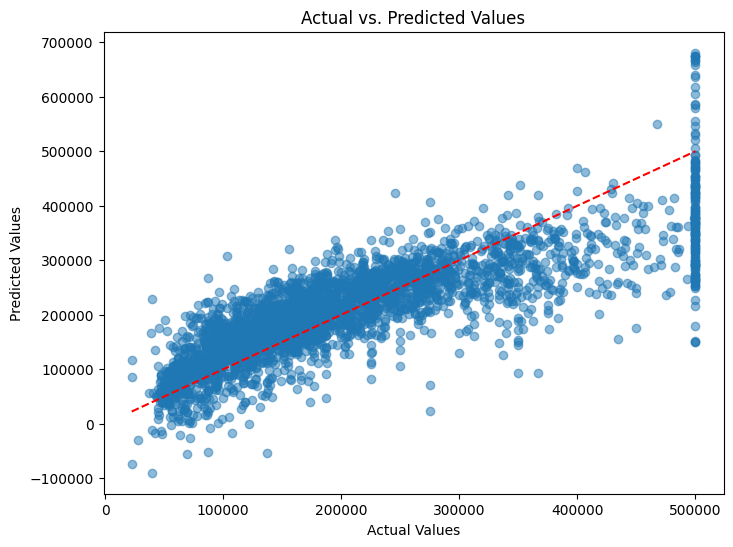

In [148]:
y_val = y_val.flatten()
y_val_prediction = y_val_prediction.flatten()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_val_prediction, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()


In [147]:
y_test_predictions=lr.predict(x_test)

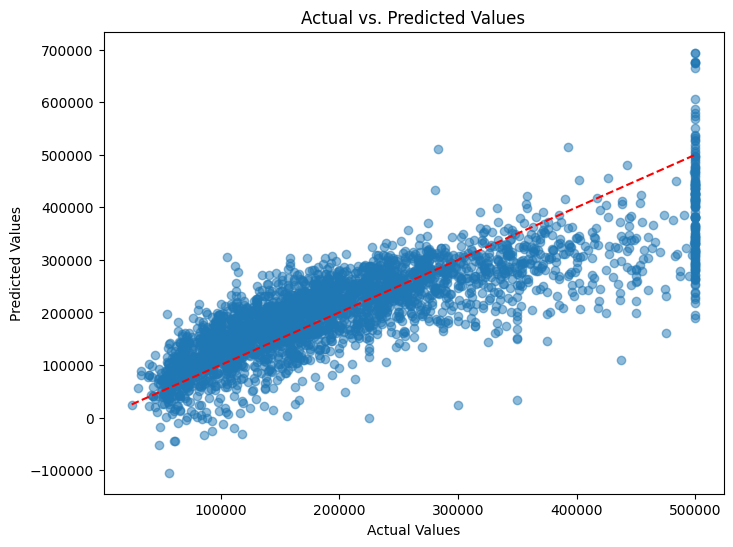

In [149]:
y_test = y_test.flatten()
y_test_prediction = y_test_predictions.flatten()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()

In [150]:
mse_test = mean_squared_error(y_test, y_test_predictions)
mae_test = mean_absolute_error(y_test, y_test_predictions)
print(mse)
print(mae)

4814917621.605248
50307.568737046466
